In [ ]:
# Load data and libraries

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from google.colab import drive
from zipfile import ZipFile

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/My Drive/Mental Health Recommendation Module/Data Sets/FER2013.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/sad/Training_65242339.jpg  
  inflating: /content/train/sad/Training_65267116.jpg  
  inflating: /content/train/sad/Training_65275626.jpg  
  inflating: /content/train/sad/Training_6529266.jpg  
  inflating: /content/train/sad/Training_65329617.jpg  
  inflating: /content/train/sad/Training_65338712.jpg  
  inflating: /content/train/sad/Training_65338797.jpg  
  inflating: /content/train/sad/Training_65387162.jpg  
  inflating: /content/train/sad/Training_65404494.jpg  
  inflating: /content/train/sad/Training_65426218.jpg  
  inflating: /content/train/sad/Training_65430136.jpg  
  inflating: /content/train/sad/Training_65437377.jpg  
  inflating: /content/train/sad/Training_6545735.jpg  
  inflating: /content/train/sad/Training_65463385.jpg  
  inflating: /content/train/sad/Training_65473985.jpg  
  inflating: /content/train/sad/Training_65502829.jpg  
  inflating: /content/train/sad/Training_65505359.jpg  

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Config
DATA_DIR = "/content/train"
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_EPOCHS = 20
SEED = 42
POSITIVE_CLASSES = ['happy', 'neutral']  # All others are considered negative

# Data Pre-Processing

In [ ]:
def show_image_transformation(dataset, transform, num_images=5):
    import torchvision.transforms.functional as F

    indices = random.sample(range(len(dataset)), num_images)
    plt.figure(figsize=(10, 4 * num_images))

    for i, idx in enumerate(indices):
        pil_img, label = dataset[idx]

        # Original image
        plt.subplot(num_images, 2, 2*i + 1)
        plt.imshow(pil_img)
        plt.title(f"Original - Class: {dataset.classes[label]}")
        plt.axis("off")

        # Transformed image
        transformed_img = transform(pil_img)
        img_np = transformed_img.permute(1, 2, 0).numpy()
        img_np = np.clip((img_np * np.array([0.229, 0.224, 0.225])) +
                         np.array([0.485, 0.456, 0.406]), 0, 1)

        plt.subplot(num_images, 2, 2*i + 2)
        plt.imshow(img_np)
        plt.title("Transformed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


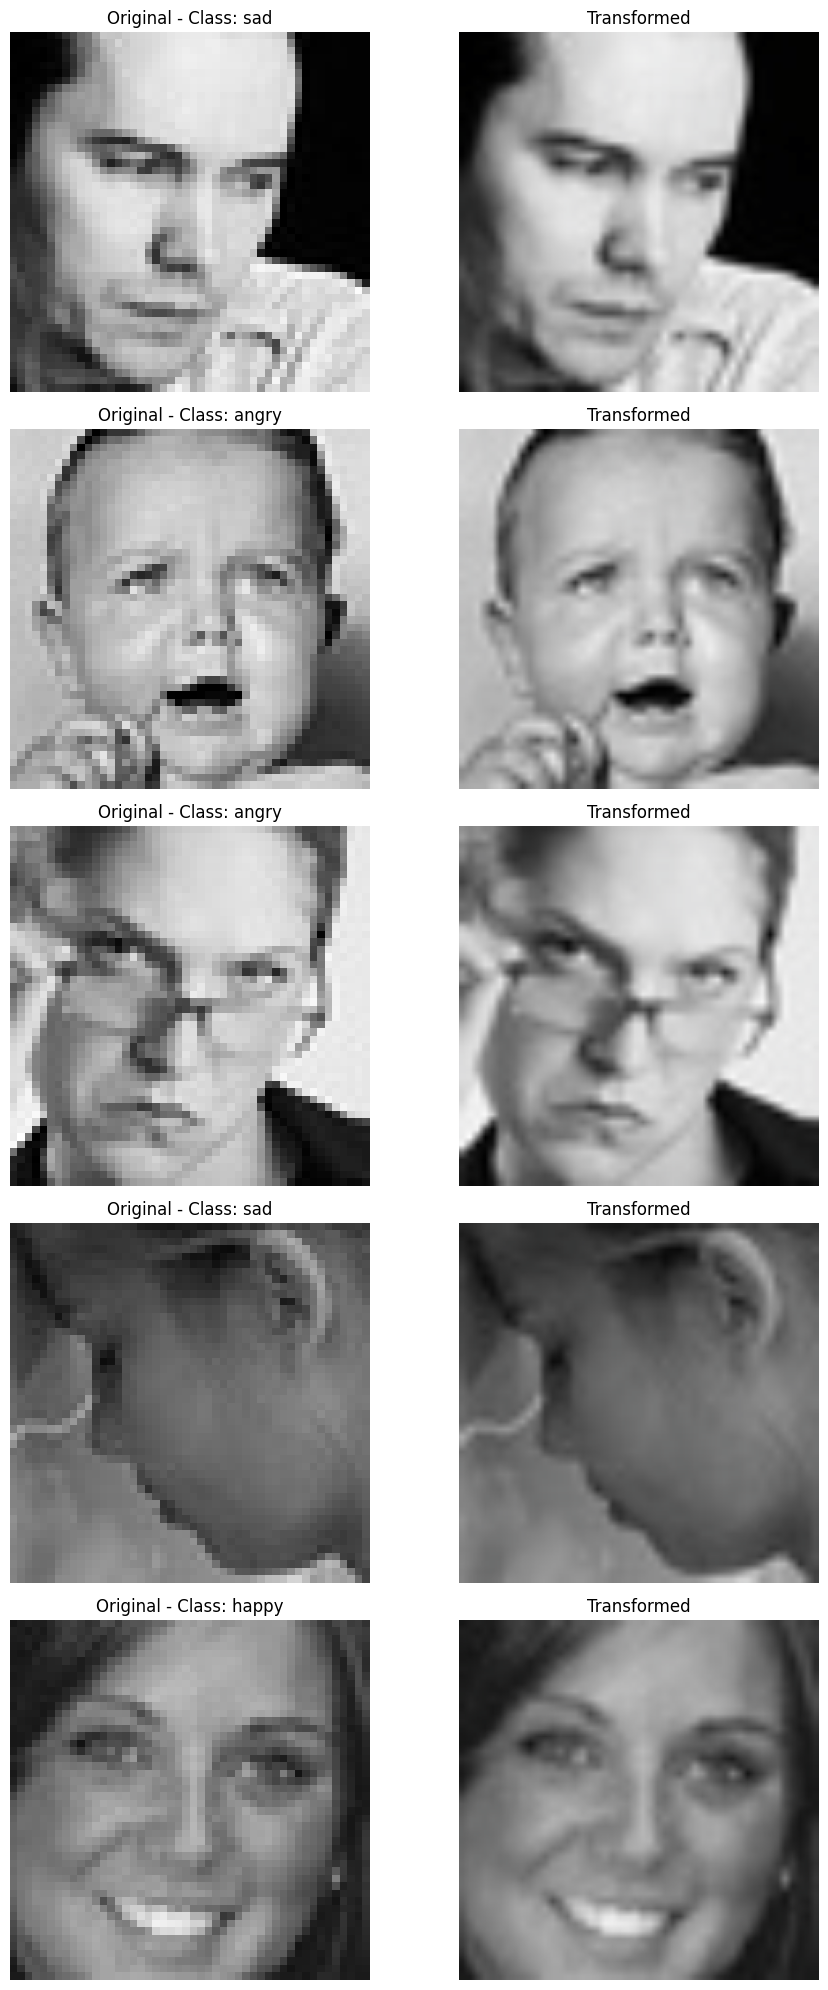

In [ ]:
# Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Transformations
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# This will show 5 random examples
show_image_transformation(ImageFolder(DATA_DIR), transform, num_images=5)

# Load dataset
dataset = ImageFolder(DATA_DIR, transform=transform)
original_classes = dataset.classes

In [ ]:
# Create a binary target wrapper
class BinaryEmotionDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, positive_classes):
        self.dataset = dataset
        self.positive_indices = [dataset.class_to_idx[c] for c in positive_classes]

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        binary_label = 1 if label in self.positive_indices else 0
        return image, torch.tensor(binary_label, dtype=torch.float32)

    def __len__(self):
        return len(self.dataset)

binary_dataset = BinaryEmotionDataset(dataset, POSITIVE_CLASSES)


# Split into train and validation

In [ ]:
# Split into train and validation
train_size = int(0.8 * len(binary_dataset))
val_size = len(binary_dataset) - train_size
train_set, val_set = random_split(binary_dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE)

# model Training and validation


Resnet 18

### Without Early stopping

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20 - Loss: 314.2344, Accuracy: 78.96%
Epoch 2/20 - Loss: 226.1601, Accuracy: 86.24%
Epoch 3/20 - Loss: 152.9608, Accuracy: 91.21%
Epoch 4/20 - Loss: 92.4697, Accuracy: 94.99%
Epoch 5/20 - Loss: 56.2230, Accuracy: 97.03%
Epoch 6/20 - Loss: 47.9443, Accuracy: 97.46%
Epoch 7/20 - Loss: 36.6265, Accuracy: 98.25%
Epoch 8/20 - Loss: 34.5571, Accuracy: 98.31%
Epoch 9/20 - Loss: 30.3902, Accuracy: 98.51%
Epoch 10/20 - Loss: 28.2628, Accuracy: 98.58%
Epoch 11/20 - Loss: 24.0098, Accuracy: 98.84%
Epoch 12/20 - Loss: 24.7945, Accuracy: 98.75%
Epoch 13/20 - Loss: 21.6490, Accuracy: 98.95%
Epoch 14/20 - Loss: 19.3031, Accuracy: 99.07%
Epoch 15/20 - Loss: 23.0997, Accuracy: 98.77%
Epoch 16/20 - Loss: 17.8256, Accuracy: 99.10%
Epoch 17/20 - Loss: 16.1549, Accuracy: 99.22%
Epoch 18/20 - Loss: 18.4069, Accuracy: 99.06%
Epoch 19/20 - Loss: 15.8316, Accuracy: 99.28%
Epoch 20/20 - Loss: 13.3041, Accuracy: 99.36%

Classification Report:
              precision    recall  f1-score   support

    Neg

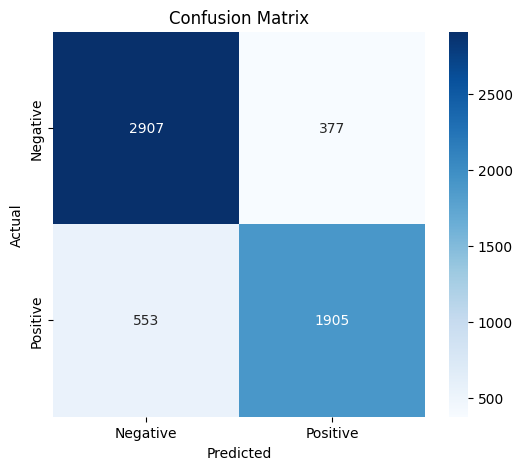

In [ ]:
# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training loop
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {running_loss:.4f}, Accuracy: {train_acc:.2f}%")

# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = torch.sigmoid(outputs) > 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().astype(int))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### With Early stopping

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 149MB/s]


Epoch 1/20 - Train Loss: 0.4361, Accuracy: 79.40%, Val Loss: 0.3949
Epoch 2/20 - Train Loss: 0.3039, Accuracy: 86.89%, Val Loss: 0.3807
Epoch 3/20 - Train Loss: 0.2039, Accuracy: 91.39%, Val Loss: 0.4198
Epoch 4/20 - Train Loss: 0.1169, Accuracy: 95.48%, Val Loss: 0.4747
Epoch 5/20 - Train Loss: 0.0814, Accuracy: 96.93%, Val Loss: 0.5232
Early stopping triggered at epoch 5

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.92      0.86      3284
    Positive       0.87      0.72      0.79      2458

    accuracy                           0.83      5742
   macro avg       0.84      0.82      0.82      5742
weighted avg       0.84      0.83      0.83      5742



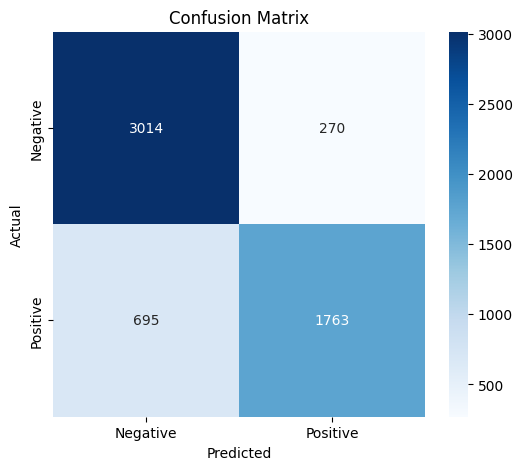

In [ ]:
# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Early stopping parameters
best_val_loss = float('inf')
patience = 3
trigger_times = 0
best_model_path = "best_model.pth"

# Training loop with early stopping
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    avg_train_loss = running_loss / len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {avg_train_loss:.4f}, Accuracy: {train_acc:.2f}%, Val Loss: {avg_val_loss:.4f}")

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load(best_model_path))

# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = torch.sigmoid(outputs) > 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().astype(int))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Resnet50
Deeper version of ResNet18, better accuracy

### Without Early stopping

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 178MB/s]


Epoch 1/20 - Loss: 310.9795, Accuracy: 79.45%
Epoch 2/20 - Loss: 235.1362, Accuracy: 85.82%
Epoch 3/20 - Loss: 177.6614, Accuracy: 89.55%
Epoch 4/20 - Loss: 124.7231, Accuracy: 93.04%
Epoch 5/20 - Loss: 82.7070, Accuracy: 95.60%
Epoch 6/20 - Loss: 61.0927, Accuracy: 96.67%
Epoch 7/20 - Loss: 44.5073, Accuracy: 97.76%
Epoch 8/20 - Loss: 43.3912, Accuracy: 97.77%
Epoch 9/20 - Loss: 33.8582, Accuracy: 98.29%
Epoch 10/20 - Loss: 31.4528, Accuracy: 98.35%
Epoch 11/20 - Loss: 31.9037, Accuracy: 98.52%
Epoch 12/20 - Loss: 25.1934, Accuracy: 98.75%
Epoch 13/20 - Loss: 24.4484, Accuracy: 98.85%
Epoch 14/20 - Loss: 23.5643, Accuracy: 98.85%
Epoch 15/20 - Loss: 21.9451, Accuracy: 98.95%
Epoch 16/20 - Loss: 20.8025, Accuracy: 98.95%
Epoch 17/20 - Loss: 21.5004, Accuracy: 98.99%
Epoch 18/20 - Loss: 20.5769, Accuracy: 99.06%
Epoch 19/20 - Loss: 18.9238, Accuracy: 99.02%
Epoch 20/20 - Loss: 15.4527, Accuracy: 99.26%

Classification Report:
              precision    recall  f1-score   support

    Ne

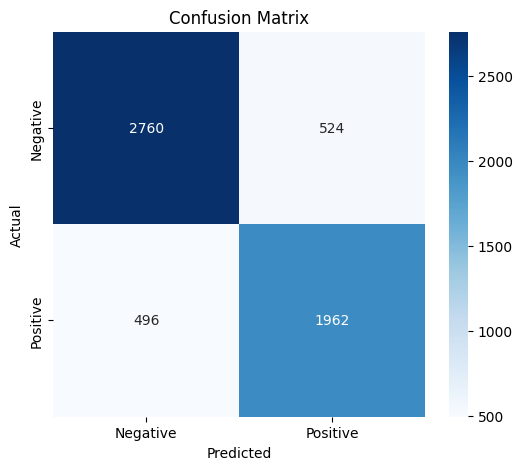

In [ ]:
# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training loop
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {running_loss:.4f}, Accuracy: {train_acc:.2f}%")

# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = torch.sigmoid(outputs) > 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().astype(int))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### With Early stopping

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


Epoch 1/20 - Train Loss: 0.4316, Accuracy: 79.44%, Val Loss: 0.3925
Epoch 2/20 - Train Loss: 0.3216, Accuracy: 85.73%, Val Loss: 0.3716
Epoch 3/20 - Train Loss: 0.2393, Accuracy: 89.98%, Val Loss: 0.3811
Epoch 4/20 - Train Loss: 0.1651, Accuracy: 93.51%, Val Loss: 0.4426
Epoch 5/20 - Train Loss: 0.1092, Accuracy: 95.89%, Val Loss: 0.6347
Early stopping triggered at epoch 5

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.91      0.86      3284
    Positive       0.86      0.72      0.79      2458

    accuracy                           0.83      5742
   macro avg       0.84      0.82      0.82      5742
weighted avg       0.83      0.83      0.83      5742



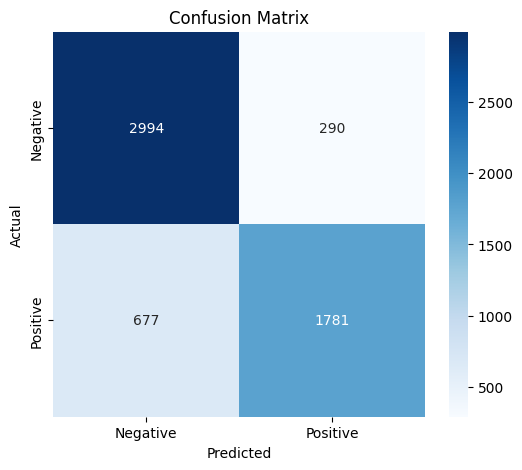

In [ ]:
# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Early stopping parameters
best_val_loss = float('inf')
patience = 3
trigger_times = 0
best_model_path = "best_model.pth"

# Training loop with early stopping
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    avg_train_loss = running_loss / len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {avg_train_loss:.4f}, Accuracy: {train_acc:.2f}%, Val Loss: {avg_val_loss:.4f}")

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load(best_model_path))

# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = torch.sigmoid(outputs) > 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().astype(int))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Efficentnet
Lightweight, good accuracy

### Without Early stopping

Epoch 1/20 - Loss: 334.6759, Accuracy: 77.52%
Epoch 2/20 - Loss: 237.1819, Accuracy: 85.38%
Epoch 3/20 - Loss: 176.1289, Accuracy: 89.32%
Epoch 4/20 - Loss: 119.8263, Accuracy: 93.33%
Epoch 5/20 - Loss: 86.7881, Accuracy: 95.22%
Epoch 6/20 - Loss: 68.0824, Accuracy: 96.36%
Epoch 7/20 - Loss: 55.5775, Accuracy: 96.97%
Epoch 8/20 - Loss: 48.0439, Accuracy: 97.55%
Epoch 9/20 - Loss: 42.3589, Accuracy: 97.88%
Epoch 10/20 - Loss: 35.9077, Accuracy: 98.17%
Epoch 11/20 - Loss: 35.5743, Accuracy: 98.15%
Epoch 12/20 - Loss: 29.5923, Accuracy: 98.49%
Epoch 13/20 - Loss: 29.2180, Accuracy: 98.44%
Epoch 14/20 - Loss: 27.4120, Accuracy: 98.58%
Epoch 15/20 - Loss: 26.0693, Accuracy: 98.65%
Epoch 16/20 - Loss: 25.1699, Accuracy: 98.77%
Epoch 17/20 - Loss: 24.7157, Accuracy: 98.91%
Epoch 18/20 - Loss: 22.1515, Accuracy: 98.88%
Epoch 19/20 - Loss: 21.7256, Accuracy: 98.98%
Epoch 20/20 - Loss: 24.8996, Accuracy: 98.88%

Classification Report:
              precision    recall  f1-score   support

    Ne

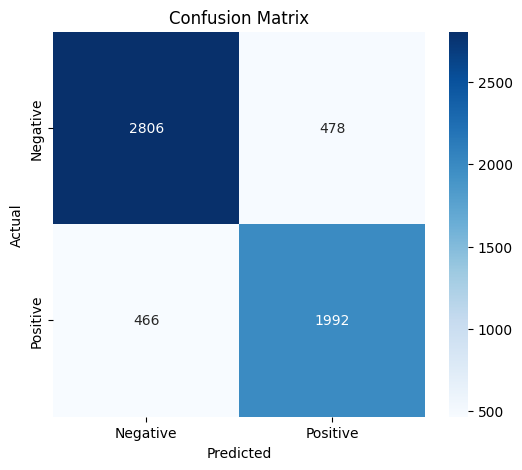

In [ ]:
# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)-

# Training loop
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {running_loss:.4f}, Accuracy: {train_acc:.2f}%")

# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = torch.sigmoid(outputs) > 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().astype(int))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### With Early stopping

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 112MB/s] 


Epoch 1/20 - Train Loss: 0.4670, Accuracy: 77.51%, Val Loss: 0.4022
Epoch 2/20 - Train Loss: 0.3316, Accuracy: 85.41%, Val Loss: 0.3799
Epoch 3/20 - Train Loss: 0.2424, Accuracy: 89.60%, Val Loss: 0.4236
Epoch 4/20 - Train Loss: 0.1797, Accuracy: 92.58%, Val Loss: 0.4446
Epoch 5/20 - Train Loss: 0.1237, Accuracy: 95.18%, Val Loss: 0.5543
Early stopping triggered at epoch 5

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.82      0.85      3284
    Positive       0.78      0.83      0.81      2458

    accuracy                           0.83      5742
   macro avg       0.82      0.83      0.83      5742
weighted avg       0.83      0.83      0.83      5742



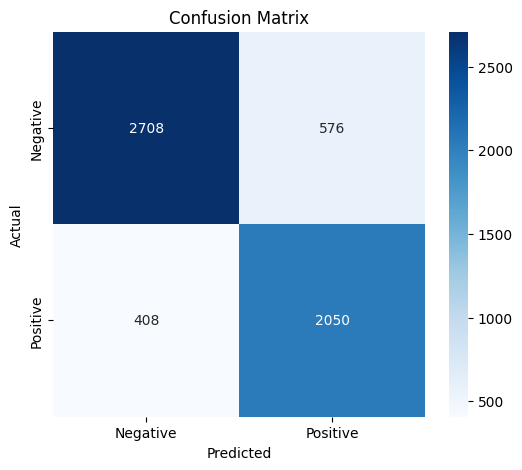

In [ ]:
# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Early stopping parameters
best_val_loss = float('inf')
patience = 3
trigger_times = 0
best_model_path = "best_model.pth"

# Training loop with early stopping
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    avg_train_loss = running_loss / len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {avg_train_loss:.4f}, Accuracy: {train_acc:.2f}%, Val Loss: {avg_val_loss:.4f}")

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load(best_model_path))

# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = torch.sigmoid(outputs) > 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().astype(int))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## VGG16
Classic architecture, slower but effective

### Without Early stopping

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth
100%|██████████| 528M/528M [00:07<00:00, 69.3MB/s]


Epoch 1/20 - Loss: 308.2627, Accuracy: 79.87%
Epoch 2/20 - Loss: 220.0379, Accuracy: 86.99%
Epoch 3/20 - Loss: 154.3874, Accuracy: 91.26%
Epoch 4/20 - Loss: 97.7445, Accuracy: 94.81%
Epoch 5/20 - Loss: 66.4406, Accuracy: 96.39%
Epoch 6/20 - Loss: 48.6606, Accuracy: 97.56%
Epoch 7/20 - Loss: 42.0066, Accuracy: 97.91%
Epoch 8/20 - Loss: 33.5025, Accuracy: 98.24%
Epoch 9/20 - Loss: 33.8920, Accuracy: 98.35%
Epoch 10/20 - Loss: 30.8744, Accuracy: 98.50%
Epoch 11/20 - Loss: 29.3219, Accuracy: 98.63%
Epoch 12/20 - Loss: 25.8141, Accuracy: 98.73%
Epoch 13/20 - Loss: 25.3525, Accuracy: 98.79%
Epoch 14/20 - Loss: 23.8199, Accuracy: 98.82%
Epoch 15/20 - Loss: 21.5482, Accuracy: 98.92%
Epoch 16/20 - Loss: 23.6393, Accuracy: 98.86%
Epoch 17/20 - Loss: 17.2220, Accuracy: 99.23%
Epoch 18/20 - Loss: 19.1848, Accuracy: 99.00%
Epoch 19/20 - Loss: 18.8485, Accuracy: 99.16%
Epoch 20/20 - Loss: 20.2565, Accuracy: 99.02%

Classification Report:
              precision    recall  f1-score   support

    Neg

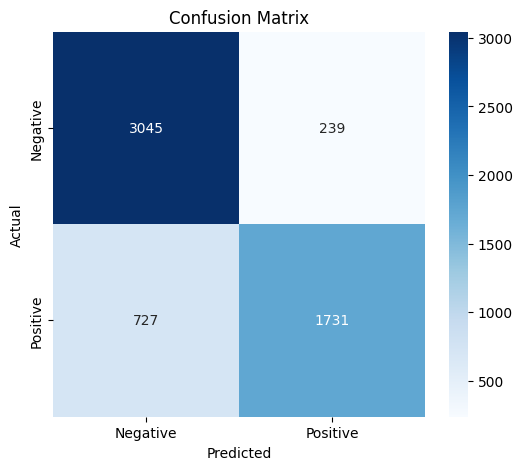

In [ ]:
# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.vgg16_bn(pretrained=True)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training loop
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {running_loss:.4f}, Accuracy: {train_acc:.2f}%")

# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = torch.sigmoid(outputs) > 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().astype(int))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### With Early stopping

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20 - Train Loss: 0.4262, Accuracy: 80.27%, Val Loss: 0.3665
Epoch 2/20 - Train Loss: 0.3063, Accuracy: 86.89%, Val Loss: 0.3668
Epoch 3/20 - Train Loss: 0.2133, Accuracy: 91.41%, Val Loss: 0.4241
Epoch 4/20 - Train Loss: 0.1338, Accuracy: 94.85%, Val Loss: 0.4756
Early stopping triggered at epoch 4

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.89      0.86      3284
    Positive       0.84      0.76      0.80      2458

    accuracy                           0.83      5742
   macro avg       0.83      0.82      0.83      5742
weighted avg       0.83      0.83      0.83      5742



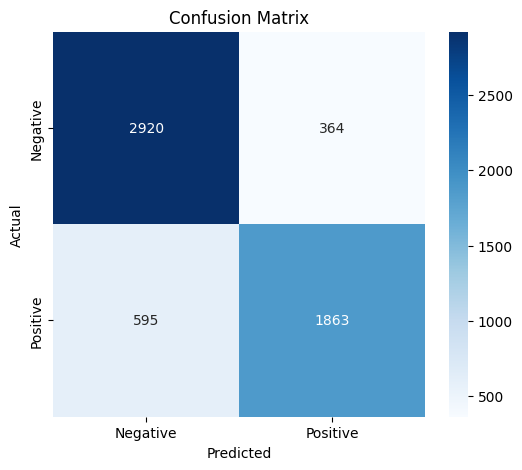

In [ ]:
# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.vgg16_bn(pretrained=True)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Early stopping parameters
best_val_loss = float('inf')
patience = 3
trigger_times = 0
best_model_path = "best_model.pth"

# Training loop with early stopping
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    avg_train_loss = running_loss / len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {avg_train_loss:.4f}, Accuracy: {train_acc:.2f}%, Val Loss: {avg_val_loss:.4f}")

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load(best_model_path))

# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = torch.sigmoid(outputs) > 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().astype(int))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## ConvNeXt
Newer architecture, strong performance

### Without Early stopping

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:01<00:00, 107MB/s]


Epoch 1/20 - Loss: 301.0900, Accuracy: 80.41%
Epoch 2/20 - Loss: 215.7432, Accuracy: 87.05%
Epoch 3/20 - Loss: 153.0685, Accuracy: 91.17%
Epoch 4/20 - Loss: 96.5534, Accuracy: 94.87%
Epoch 5/20 - Loss: 62.9496, Accuracy: 96.71%
Epoch 6/20 - Loss: 47.6411, Accuracy: 97.56%
Epoch 7/20 - Loss: 36.6175, Accuracy: 98.22%
Epoch 8/20 - Loss: 34.3545, Accuracy: 98.30%
Epoch 9/20 - Loss: 31.4863, Accuracy: 98.35%
Epoch 10/20 - Loss: 22.3412, Accuracy: 98.93%
Epoch 11/20 - Loss: 25.0952, Accuracy: 98.77%
Epoch 12/20 - Loss: 24.0693, Accuracy: 98.81%
Epoch 13/20 - Loss: 22.8462, Accuracy: 98.89%
Epoch 14/20 - Loss: 19.9375, Accuracy: 99.02%
Epoch 15/20 - Loss: 19.4107, Accuracy: 99.05%
Epoch 16/20 - Loss: 18.0069, Accuracy: 99.14%
Epoch 17/20 - Loss: 16.2576, Accuracy: 99.18%
Epoch 18/20 - Loss: 17.7123, Accuracy: 99.12%
Epoch 19/20 - Loss: 17.7159, Accuracy: 99.10%
Epoch 20/20 - Loss: 16.0253, Accuracy: 99.21%

Classification Report:
              precision    recall  f1-score   support

    Neg

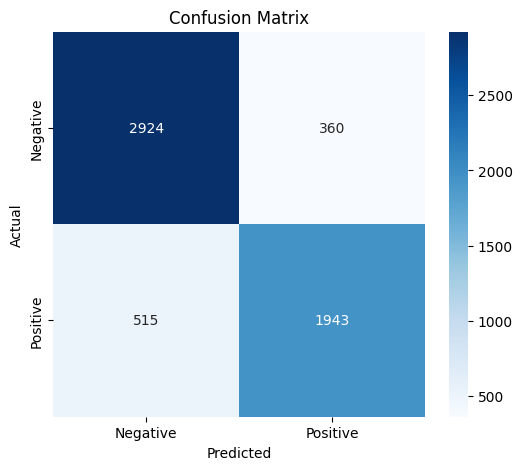

In [ ]:
# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.convnext_tiny(pretrained=True)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training loop
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {running_loss:.4f}, Accuracy: {train_acc:.2f}%")

# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = torch.sigmoid(outputs) > 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().astype(int))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



### With Early stopping

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:00<00:00, 168MB/s] 


Epoch 1/20 - Train Loss: 0.4128, Accuracy: 80.42%, Val Loss: 0.3490
Epoch 2/20 - Train Loss: 0.2930, Accuracy: 87.50%, Val Loss: 0.3388
Epoch 3/20 - Train Loss: 0.2035, Accuracy: 91.69%, Val Loss: 0.3489
Epoch 4/20 - Train Loss: 0.1340, Accuracy: 94.84%, Val Loss: 0.3996
Epoch 5/20 - Train Loss: 0.0896, Accuracy: 96.78%, Val Loss: 0.4659
Early stopping triggered at epoch 5

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.84      0.87      3284
    Positive       0.80      0.87      0.84      2458

    accuracy                           0.85      5742
   macro avg       0.85      0.86      0.85      5742
weighted avg       0.86      0.85      0.86      5742



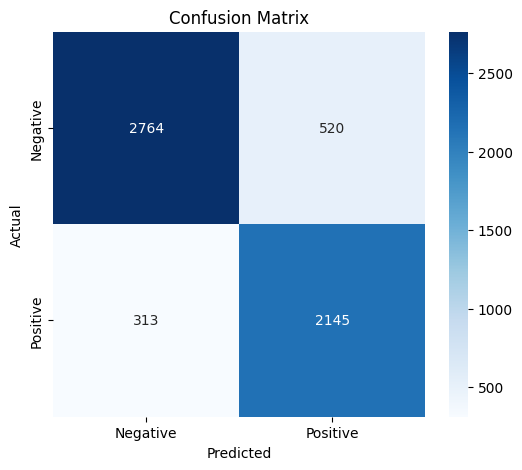

In [ ]:
# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.convnext_tiny(pretrained=True)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Early stopping parameters
best_val_loss = float('inf')
patience = 3
trigger_times = 0
best_model_path = "best_model.pth"

# Training loop with early stopping
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    avg_train_loss = running_loss / len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {avg_train_loss:.4f}, Accuracy: {train_acc:.2f}%, Val Loss: {avg_val_loss:.4f}")

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load(best_model_path))

# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = torch.sigmoid(outputs) > 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().astype(int))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Swin Transformer
Vision Transformer-style, high performance

### Without Early stopping

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Swin_V2_T_Weights.IMAGENET1K_V1`. You can also use `weights=Swin_V2_T_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20 - Loss: 365.4497, Accuracy: 74.10%
Epoch 2/20 - Loss: 274.7934, Accuracy: 82.71%
Epoch 3/20 - Loss: 231.5393, Accuracy: 85.84%
Epoch 4/20 - Loss: 194.0707, Accuracy: 88.72%
Epoch 5/20 - Loss: 160.5596, Accuracy: 90.97%
Epoch 6/20 - Loss: 130.5332, Accuracy: 92.91%
Epoch 7/20 - Loss: 101.4722, Accuracy: 94.51%
Epoch 8/20 - Loss: 83.6186, Accuracy: 95.54%
Epoch 9/20 - Loss: 73.7060, Accuracy: 96.05%
Epoch 10/20 - Loss: 62.1964, Accuracy: 96.76%
Epoch 11/20 - Loss: 53.4489, Accuracy: 97.24%
Epoch 12/20 - Loss: 51.3365, Accuracy: 97.39%
Epoch 13/20 - Loss: 46.8356, Accuracy: 97.53%
Epoch 14/20 - Loss: 43.7424, Accuracy: 97.74%
Epoch 15/20 - Loss: 40.8556, Accuracy: 97.90%
Epoch 16/20 - Loss: 39.3548, Accuracy: 97.94%
Epoch 17/20 - Loss: 36.5776, Accuracy: 98.19%
Epoch 18/20 - Loss: 39.7048, Accuracy: 97.87%
Epoch 19/20 - Loss: 33.7718, Accuracy: 98.24%
Epoch 20/20 - Loss: 35.8473, Accuracy: 98.15%

Classification Report:
              precision    recall  f1-score   support

   

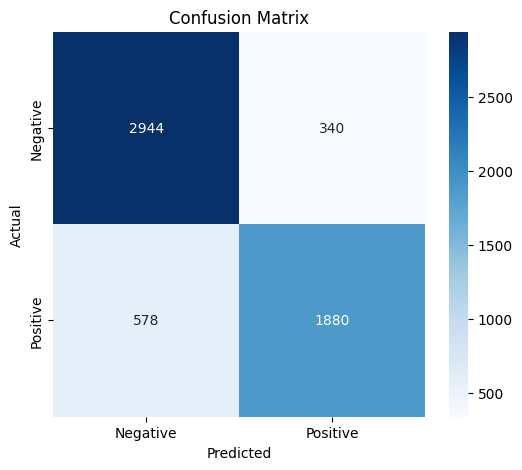

In [ ]:
# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.swin_v2_t(pretrained=True)
model.head = nn.Linear(model.head.in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training loop
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {running_loss:.4f}, Accuracy: {train_acc:.2f}%")

# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = torch.sigmoid(outputs) > 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().astype(int))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
torch.save(model.state_dict(), "binary_emotion_resnet18.pth")


### With Early stopping

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Swin_V2_T_Weights.IMAGENET1K_V1`. You can also use `weights=Swin_V2_T_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/swin_v2_t-b137f0e2.pth" to /root/.cache/torch/hub/checkpoints/swin_v2_t-b137f0e2.pth
100%|██████████| 109M/109M [00:00<00:00, 161MB/s] 


Epoch 1/20 - Train Loss: 0.5009, Accuracy: 75.39%, Val Loss: 0.4088
Epoch 2/20 - Train Loss: 0.3804, Accuracy: 82.96%, Val Loss: 0.3785
Epoch 3/20 - Train Loss: 0.3221, Accuracy: 86.31%, Val Loss: 0.3755
Epoch 4/20 - Train Loss: 0.2707, Accuracy: 88.60%, Val Loss: 0.3759
Epoch 5/20 - Train Loss: 0.2244, Accuracy: 90.72%, Val Loss: 0.4173
Epoch 6/20 - Train Loss: 0.1736, Accuracy: 93.03%, Val Loss: 0.4419
Early stopping triggered at epoch 6

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.88      0.86      3284
    Positive       0.82      0.78      0.80      2458

    accuracy                           0.83      5742
   macro avg       0.83      0.83      0.83      5742
weighted avg       0.83      0.83      0.83      5742



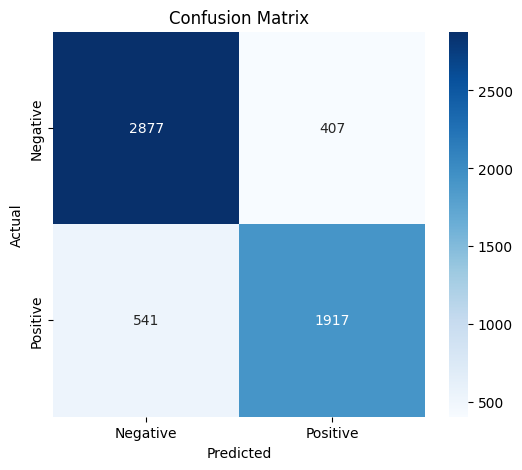

In [ ]:
# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.swin_v2_t(pretrained=True)
model.head = nn.Linear(model.head.in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Early stopping parameters
best_val_loss = float('inf')
patience = 3
trigger_times = 0
best_model_path = "best_model.pth"

# Training loop with early stopping
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    avg_train_loss = running_loss / len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {avg_train_loss:.4f}, Accuracy: {train_acc:.2f}%, Val Loss: {avg_val_loss:.4f}")

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load(best_model_path))

# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = torch.sigmoid(outputs) > 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().astype(int))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
